## Project - part 2.1

Для анализа был выбран датасет Bank Marketing (данные португальского банка)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


bank = pd.read_csv('bank-additional-full.csv', delimiter=';')

Сразу выведем наш датафрейм

In [ ]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


Проверим на тип

In [ ]:
bank.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


Выведем сводку по числовым признакам

In [ ]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
for i in bank.columns:
    print(bank[f'{i}'].value_counts())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, 

Колонки со значением 'unknown':

job - 330

marital - 80

education - 1,731

default - 8,597

housing - 990

loan - 990

In [ ]:
bank['unknown_count'] = (bank[['job', 'marital', 'education', 'default', 'housing', 'loan']] == 'unknown').sum(axis=1)

In [ ]:
bank['unknown_count'].value_counts()

,count
unknown_count,
0,30488
1,9034
2,1338
3,306
4,20
5,2


<Axes: xlabel='y', ylabel='count'>

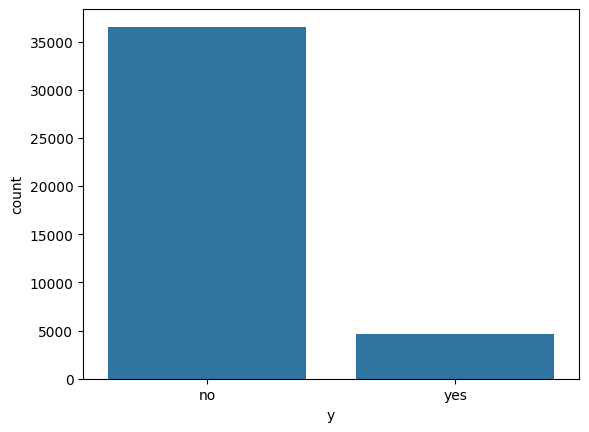

In [ ]:
sns.countplot(x='y', data=bank)

In [ ]:
bank.count()

,0
age,41188
job,41188
marital,41188
education,41188
default,41188
housing,41188
loan,41188
contact,41188
month,41188
day_of_week,41188


In [ ]:
bank[bank['y'] == 'no'].count()/41188*100

,0
age,88.734583
job,88.734583
marital,88.734583
education,88.734583
default,88.734583
housing,88.734583
loan,88.734583
contact,88.734583
month,88.734583
day_of_week,88.734583


In [ ]:
bank[bank['y'] == 'yes'].count()/41188*100

,0
age,11.265417
job,11.265417
marital,11.265417
education,11.265417
default,11.265417
housing,11.265417
loan,11.265417
contact,11.265417
month,11.265417
day_of_week,11.265417


### Пользователи, намеренно скрывающие информацию о кредитной истории

Проверка, являются ли клиенты со значением unknown в колонках housing и loan одними и теми же (так как видно что их по 990 в каждой колонке)

In [ ]:
bank[(bank['housing'] == 'unknown') & (bank['loan'] == 'unknown')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,4
81,51,blue-collar,married,basic.4y,unknown,unknown,unknown,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
261,27,blue-collar,single,basic.6y,no,unknown,unknown,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
385,59,management,married,basic.4y,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
401,48,services,married,high.school,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40990,31,admin.,single,university.degree,no,unknown,unknown,cellular,oct,tue,...,3,1,success,-1.1,94.601,-49.5,1.008,4963.6,yes,2
41014,31,technician,single,professional.course,no,unknown,unknown,cellular,oct,thu,...,999,0,nonexistent,-1.1,94.601,-49.5,1.025,4963.6,yes,2
41015,34,admin.,divorced,university.degree,no,unknown,unknown,cellular,oct,thu,...,999,1,failure,-1.1,94.601,-49.5,1.025,4963.6,no,2
41029,46,management,married,university.degree,no,unknown,unknown,cellular,oct,mon,...,12,2,failure,-1.1,94.601,-49.5,1.032,4963.6,no,2


Мы выявили новую группу, которые потенциально целенаправленно скрывают данные своей кридитной истории, их 990 человека (около 2.2% от общего количества клиентов). Поэтому сравним общую конверсию этой скрытой группы и остальных клиентов.

In [ ]:
bank[(bank['housing'] == 'unknown') & (bank['loan'] == 'unknown') & (bank['y'] == 'yes')]['y'].count()/990

np.float64(0.10808080808080808)

Мы видим, что конверсия нашей группы равна около 10.8%. Конверсия же остальных клиентов равна 11.28%

In [ ]:
bank[(bank['housing'] != 'unknown') & (bank['loan'] != 'unknown') & (bank['y'] == 'yes')]['y'].count()/(41188 - 990)

np.float64(0.11276680431862282)

In [ ]:
bank[(bank['y'] == 'yes') & (bank['housing'] != 'unknown') & (bank['loan'] != 'unknown')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
75,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,1
83,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,1
88,49,technician,married,basic.9y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,0
129,41,technician,married,professional.course,unknown,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,1
139,45,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41174,62,retired,married,university.degree,no,yes,no,cellular,nov,thu,...,1,6,success,-1.1,94.767,-50.8,1.031,4963.6,yes,0
41178,62,retired,married,university.degree,no,no,no,cellular,nov,thu,...,6,3,success,-1.1,94.767,-50.8,1.031,4963.6,yes,0
41181,37,admin.,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,0
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,0


In [ ]:
bank[(bank['housing'] == 'unknown') & (bank['loan'] == 'unknown') & (bank['y'] == 'yes')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
3570,31,blue-collar,married,basic.6y,unknown,unknown,unknown,telephone,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,yes,3
4522,27,blue-collar,married,basic.6y,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,yes,3
7475,52,services,married,high.school,unknown,unknown,unknown,telephone,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,yes,3
10171,43,blue-collar,married,basic.4y,no,unknown,unknown,telephone,jun,thu,...,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,yes,2
10977,41,services,married,high.school,no,unknown,unknown,telephone,jun,wed,...,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40875,57,admin.,married,university.degree,no,unknown,unknown,cellular,oct,wed,...,3,2,success,-1.1,94.601,-49.5,0.959,4963.6,yes,2
40941,66,retired,married,basic.4y,unknown,unknown,unknown,cellular,oct,wed,...,6,3,success,-1.1,94.601,-49.5,0.985,4963.6,yes,3
40990,31,admin.,single,university.degree,no,unknown,unknown,cellular,oct,tue,...,3,1,success,-1.1,94.601,-49.5,1.008,4963.6,yes,2
41014,31,technician,single,professional.course,no,unknown,unknown,cellular,oct,thu,...,999,0,nonexistent,-1.1,94.601,-49.5,1.025,4963.6,yes,2


Проводим z-test для пропорций

In [ ]:
from scipy.stats import chi2_contingency

c_table = np.array([[4533, 41188-4533-990], [107, 990-107]])
chi2_contingency(c_table)

Chi2ContingencyResult(statistic=np.float64(0.16795381809777024), pvalue=np.float64(0.6819367535513042), dof=1, expected_freq=array([[ 4528.47237059, 35669.52762941],
       [  111.52762941,   878.47237059]]))

Таким образом у нас нет оснований отвергать нулевую гипотезу об однородности выборок скрытных клиентов и всех остальных. Поэтому эти клиенты не будут влиять на анализ по кредитной истории

### Пользователи с отсутствием дефолта

Проанализируем пропуски по колонке default. Из вышеупомянутого у нас 8597 строк с неизвестным значением, это около 20%. С этим надо что-то делать! Свяжем колонку дефолт с предыдущими хаосинг и лоан. Посмотрим сколько клиентов у которых нет ни одного вида кредита и неизвестно наличие дефолта.

In [ ]:
bank[(bank['default'] == 'unknown') & (bank['loan'] == 'no') & (bank['housing'] == 'no')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
19,39,management,single,basic.9y,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40673,45,unemployed,married,professional.course,unknown,no,no,cellular,sep,thu,...,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,yes,1
40702,82,retired,married,university.degree,unknown,no,no,cellular,sep,mon,...,3,4,success,-1.1,94.199,-37.5,0.879,4963.6,no,1
40714,84,retired,divorced,unknown,unknown,no,no,cellular,sep,tue,...,3,2,success,-1.1,94.199,-37.5,0.877,4963.6,yes,2
40886,70,retired,married,basic.4y,unknown,no,no,cellular,oct,thu,...,14,3,failure,-1.1,94.601,-49.5,0.965,4963.6,no,1


Таких вышло 3457 строк! Это некая логическая ошибка. Ведь если у клиента нет ни одного вида кредита то у него и дефолта не может быть. Поэтому заменяем значения 'unknown' на 'no'

In [ ]:
mask = (bank['default'] == 'unknown') & (bank['loan'] == 'no') & (bank['housing'] == 'no')
bank.loc[mask, 'default'] = 'no'

Создаём маску (логический фильтр) для тех самых 3,457 клиентов и меняем их статус с 'unknown' на 'no'.

Результат:
До исправления:

unknown: 8,597 клиентов (19%)

no: 32,588 клиентов (72%)

yes: 3 клиента (0.007%)

После исправления:

unknown: 5,140 клиентов (11%) ← только те, у кого ЕСТЬ кредиты

no: 36,045 клиентов (80%) ← добавили исправленных

yes: 3 клиента (0.007%)

In [ ]:
bank['default'].value_counts()

,count
default,
no,36045
unknown,5140
yes,3


In [ ]:
bank[(bank['default'] == 'unknown') & (bank['loan'] == 'unknown') & (bank['housing'] == 'unknown')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,4
81,51,blue-collar,married,basic.4y,unknown,unknown,unknown,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
385,59,management,married,basic.4y,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
401,48,services,married,high.school,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
470,42,technician,single,professional.course,unknown,unknown,unknown,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34618,33,blue-collar,married,basic.9y,unknown,unknown,unknown,cellular,may,thu,...,999,0,nonexistent,-1.8,92.893,-46.2,1.266,5099.1,no,3
34826,59,management,married,basic.4y,unknown,unknown,unknown,cellular,may,thu,...,999,1,failure,-1.8,92.893,-46.2,1.266,5099.1,no,3
34970,42,self-employed,married,professional.course,unknown,unknown,unknown,cellular,may,fri,...,999,0,nonexistent,-1.8,92.893,-46.2,1.250,5099.1,no,3
37661,71,retired,married,basic.4y,unknown,unknown,unknown,cellular,aug,tue,...,999,0,nonexistent,-2.9,92.201,-31.4,0.859,5076.2,yes,3


Слишком мало тех кто скрывает свою кредитную историю

Но проведем z-test для определения однородности группы со значением unknown в default и остальных людей

In [ ]:
bank[(bank['default'] == 'unknown') & (bank['y'] == 'yes')]['y'].count()

np.int64(260)

In [ ]:
bank[(bank['default'] == 'unknown') & (bank['y'] == 'no')]['y'].count()

np.int64(4880)

In [ ]:
bank[(bank['default'] != 'unknown') & (bank['y'] == 'yes')]['y'].count()

np.int64(4380)

In [ ]:
bank[(bank['default'] != 'unknown') & (bank['y'] == 'no')]['y'].count()

np.int64(31668)

Сравниваем конверсию (долю "yes") между двумя группами:

Клиенты с default='unknown' (после исправления)

Все остальные клиенты (default='no' или 'yes')

In [ ]:
from scipy.stats import chi2_contingency

c_table = np.array([[4380, 	31668], [260, 4880]])
chi2_contingency(c_table)

Chi2ContingencyResult(statistic=np.float64(225.64245985722286), pvalue=np.float64(5.3172639569772205e-51), dof=1, expected_freq=array([[ 4060.95756045, 31987.04243955],
       [  579.04243955,  4560.95756045]]))

χ² = 225.6 (очень большая величина)

p-value = 5.3e-51 (практически 0)

Статистический вывод: Разница между группами ОЧЕНЬ значима!

Конверсия по группам:
Клиенты с unknown default: 260/5,140 = 5.06%

Все остальные клиенты: 4,380/36,048 = 12.15%

Ключевой инсайт:
Клиенты с неизвестной кредитной историей соглашаются на депозит в 2.4 раза реже!

Почему это важно для бизнеса:
1. Экономия ресурсов:
Банк тратит время менеджеров на звонки клиентам, которые почти никогда не соглашаются (только 5% конверсии).

2. Приоритизация:
Нужно фокусироваться на клиентах с default='no' — у них конверсия в 2.4 раза выше!

3. Качество данных:
Мы обнаружили и исправили логическую ошибку в данных, что улучшило качество анализа.

### Остальное

In [ ]:
bank['contact'].value_counts()

,count
contact,
cellular,26144
telephone,15044


In [ ]:
bank[bank['contact'] == 'cellular']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,unknown_count
12357,45,blue-collar,married,basic.9y,no,yes,no,cellular,jul,fri,...,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,0
12358,29,entrepreneur,married,high.school,no,yes,no,cellular,jul,fri,...,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,0
12360,33,technician,married,basic.9y,unknown,yes,no,cellular,jul,fri,...,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,1
12361,41,management,married,university.degree,no,yes,no,cellular,jul,fri,...,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,0
12363,30,services,divorced,high.school,no,yes,yes,cellular,jul,fri,...,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,0


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'university.degree'),
  Text(1, 0, 'high.school'),
  Text(2, 0, 'basic.9y'),
  Text(3, 0, 'professional.course'),
  Text(4, 0, 'basic.4y'),
  Text(5, 0, 'basic.6y'),
  Text(6, 0, 'unknown'),
  Text(7, 0, 'illiterate')])

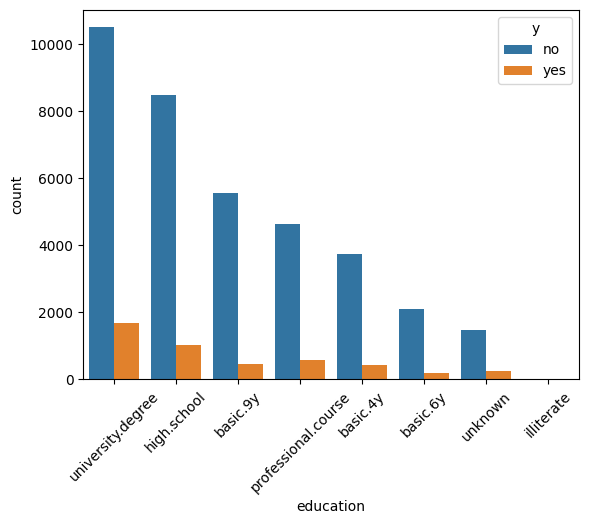

In [ ]:
sns.countplot(x='education', data=bank, hue='y', order=bank['education'].value_counts().index)
plt.xticks(rotation=45)